# Multires 2K — noisy training + trace L1 loss (λ search)

**Sections:** 1 λ train · 2 λ plots · 3 SNR sweeps · **3b convergence rate (<10%)** · **4 example @ 5 dB** · **5 example @ 0 dB** · **6 SNR 0 dB train + sweep/convergence** (scroll to bottom)

**Protocol**
- Train **Multires 2K** on **noisy traces** (SNR uniform **5–30 dB**).
- Loss: `L1_pulse + λ · (L1_trace_sum / trace_scale)` (trace vs. **clean** reference).
- Val: **200** pulses @ **15 dB**; early stopping on val pulse L1.
- **5** λ values in **[0, 3]**; pick λ* = argmin best val L1.
- Test SNR sweep (−10…30 dB): **Multires 2K + trace (λ\*)**, **Multires 60K**, **PCGPA** (cached sweeps; see Section 3).

In [1]:
import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

SRC = Path.cwd()
if not (SRC / "train.py").exists():
    SRC = SRC.parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from evaluate_cnn import load_cnn_sweep, plot_metric_curves
from pulse_metrics import snr_db_to_equivalent_n_pulses

SEED = 0
N_TRAIN = 2048
N_VAL = 200
N_TEST = 512
TRAIN_SNR_DB_RANGE = (5.0, 30.0)
VAL_SNR_DB = 15.0
LAMBDA_GRID = np.linspace(0.0, 3.0, 5)
MAX_EPOCHS = 200
PATIENCE = 25
SNR_SWEEP_DB = np.arange(-10.0, 31.0, 5.0)

RESULTS_NPZ = SRC / "checkpoints/benchmark/multires_2k_noisy_trace_lambda.npz"
META_JSON = SRC / "checkpoints/benchmark/multires_2k_noisy_trace_lambda_meta.json"
CKPT_DIR = SRC / "checkpoints/benchmark/multires_2k_noisy_trace_lambda"
OPT_CKPT = SRC / "checkpoints/benchmark/multires_2k_noisy_trace_lambda_opt.pt"
PHYS_SWEEP = SRC / "checkpoints/benchmark/multires_2k_noisy_trace_lambda_cnn_sweep.npz"

MULTIRES_60K_SWEEP = SRC / "checkpoints/large_60k_multires_50ep_cnn_sweep.npz"
MULTIRES_2K_SWEEP = SRC / "checkpoints/large_2k_multires_50ep_cnn_sweep.npz"
PCGPA_SWEEP = SRC / "checkpoints/pcgpa_snr_sweep.npz"
CONVERGENCE_FRAC_NPZ = SRC / "checkpoints/benchmark/multires_sim_convergence_frac_lt_0p1.npz"

RUN_TRAINING = False  # set True to (re)train λ grid
FORCE_RETRAIN = False

## 1. Train λ grid + SNR sweep (optimal λ)

In [2]:
script = SRC / "scripts/run_multires_2k_noisy_trace_lambda.py"
cmd = [
    sys.executable,
    str(script),
    "--seed", str(SEED),
    "--n-train", str(N_TRAIN),
    "--n-val", str(N_VAL),
    "--n-test", str(N_TEST),
    "--max-epochs", str(MAX_EPOCHS),
    "--patience", str(PATIENCE),
    "--train-snr-min", str(TRAIN_SNR_DB_RANGE[0]),
    "--train-snr-max", str(TRAIN_SNR_DB_RANGE[1]),
    "--val-snr-db", str(VAL_SNR_DB),
    "--lambda-min", "0",
    "--lambda-max", "3",
    "--lambda-steps", "5",
]
if FORCE_RETRAIN:
    cmd.append("--force")
elif RESULTS_NPZ.exists():
    cmd.append("--resume")

if RUN_TRAINING:
    print("Running:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(SRC))
    if proc.returncode != 0:
        raise RuntimeError(f"training script failed (exit {proc.returncode})")
else:
    print("RUN_TRAINING=False — loading existing artifacts only.")

assert RESULTS_NPZ.exists(), f"Missing {RESULTS_NPZ} — run training first."
assert META_JSON.exists(), f"Missing {META_JSON}"
d = np.load(RESULTS_NPZ)
print(f"λ* = {float(d['lambda_opt']):.4f}  best val L1 = {float(d['best_val_at_opt']):.5f}")
print(f"trace_scale = {float(d['trace_scale']):.4f}")

RUN_TRAINING=False — loading existing artifacts only.
λ* = 1.5000  best val L1 = 3.28530
trace_scale = 7.7392


## 2. λ optimization — val L1 vs λ and vs epoch

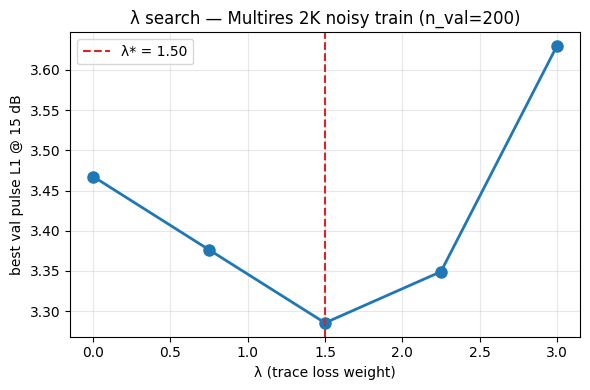

Per-λ summary:
  λ=0.0000  best_epoch= 36  stopped= 61  best_val_L1=3.46735
  λ=0.7500  best_epoch= 67  stopped= 92  best_val_L1=3.37621
  λ=1.5000  best_epoch=157  stopped=182  best_val_L1=3.28530
  λ=2.2500  best_epoch=183  stopped=200  best_val_L1=3.34904
  λ=3.0000  best_epoch= 59  stopped= 84  best_val_L1=3.62960


In [3]:
with open(META_JSON, encoding="utf-8") as f:
    run_log = json.load(f)

lambda_grid = np.array([e["lam"] for e in run_log], dtype=np.float64)
best_val = np.array([e["best_val_l1"] for e in run_log], dtype=np.float64)
best_epochs = np.array([e["best_epoch"] for e in run_log], dtype=np.int32)
lambda_opt = float(lambda_grid[int(np.argmin(best_val))])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lambda_grid, best_val, "o-", lw=2, ms=8)
ax.axvline(lambda_opt, color="C3", ls="--", lw=1.5, label=f"λ* = {lambda_opt:.2f}")
ax.set_xlabel("λ (trace loss weight)")
ax.set_ylabel(f"best val pulse L1 @ {VAL_SNR_DB:.0f} dB")
ax.set_title(f"λ search — Multires 2K noisy train (n_val={N_VAL})")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print("Per-λ summary:")
for e in run_log:
    print(
        f"  λ={e['lam']:.4f}  best_epoch={e['best_epoch']:3d}  "
        f"stopped={e['stopped_epoch']:3d}  best_val_L1={e['best_val_l1']:.5f}"
    )

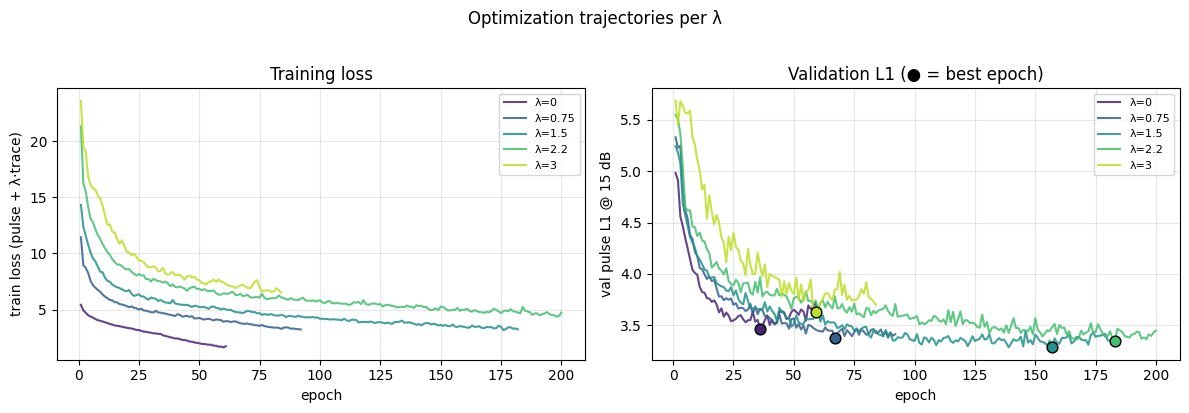

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(run_log)))

for e, c in zip(run_log, colors):
    lam = e["lam"]
    epochs = np.arange(1, len(e["val_l1_pulses"]) + 1)
    axes[0].plot(epochs, e["train_losses"], color=c, alpha=0.85, label=f"λ={lam:.2g}")
    axes[1].plot(epochs, e["val_l1_pulses"], color=c, alpha=0.85, label=f"λ={lam:.2g}")
    be = int(e["best_epoch"])
    axes[1].scatter([be], [e["val_l1_pulses"][be - 1]], color=c, s=60, edgecolors="k", zorder=5)

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("train loss (pulse + λ·trace)")
axes[0].set_title("Training loss")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel(f"val pulse L1 @ {VAL_SNR_DB:.0f} dB")
axes[1].set_title("Validation L1 (● = best epoch)")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle("Optimization trajectories per λ", y=1.02)
fig.tight_layout()
plt.show()

## 3. Test SNR sweep — Multires 2K + trace, Multires 60K, PCGPA

Load pre-computed SNR sweeps only (no retraining). Metrics: **best-ambiguity** L1 and SIMILARITY_ERROR vs. trace SNR (−10…30 dB).

**Test set sizes used in the cached sweeps below:**
- **Multires 2K + trace loss (λ\*)**: 512 held-out Gaussian synthetic test pulses (`N_TEST`, `seed=0`).
- **Multires 60K**: 512 held-out Gaussian synthetic test pulses (same generator and seed as above).
- **PCGPA**: 32 test pulses (subsample of the 512-pulse test set; `PCGPA_N_TEST=32` in `reconstruction_snr_experiments.ipynb`). Best ambiguity; maxiter=200, 3 restarts.


In [5]:
assert PHYS_SWEEP.exists(), f"Missing {PHYS_SWEEP}"
assert MULTIRES_60K_SWEEP.exists(), f"Missing {MULTIRES_60K_SWEEP}"
assert PCGPA_SWEEP.exists(), f"Missing {PCGPA_SWEEP}"

with open(META_JSON, encoding="utf-8") as f:
    _run_log = json.load(f)
_best_val = np.array([e["best_val_l1"] for e in _run_log], dtype=np.float64)
_lam_grid = np.array([e["lam"] for e in _run_log], dtype=np.float64)
lambda_opt = float(_lam_grid[int(np.argmin(_best_val))])

sweep_trace = load_cnn_sweep(PHYS_SWEEP)
sweep_trace.experiment_name = f"Multires 2K + trace (λ*={lambda_opt:.2g})"
sweep_60k = load_cnn_sweep(MULTIRES_60K_SWEEP)
sweep_60k.experiment_name = "Multires 60K"

_pcgpa_z = np.load(PCGPA_SWEEP)
pcgpa_n_test = int(_pcgpa_z["pcgpa_n_test"]) if "pcgpa_n_test" in _pcgpa_z else 32
print(f"Loaded sweeps: trace={PHYS_SWEEP.name}, 60K={MULTIRES_60K_SWEEP.name}, PCGPA={PCGPA_SWEEP.name} (n={pcgpa_n_test})")


Loaded sweeps: trace=multires_2k_noisy_trace_lambda_cnn_sweep.npz, 60K=large_60k_multires_50ep_cnn_sweep.npz, PCGPA=pcgpa_snr_sweep.npz (n=32)


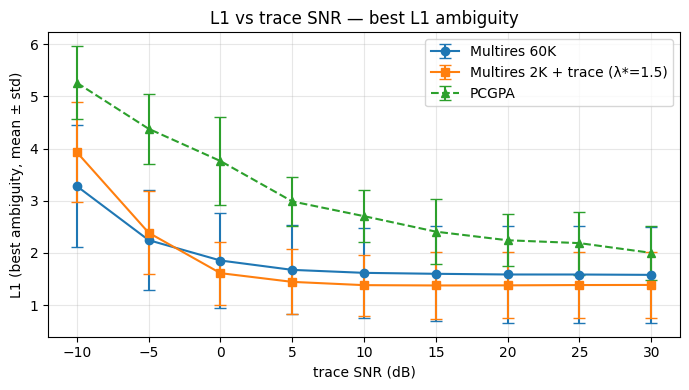

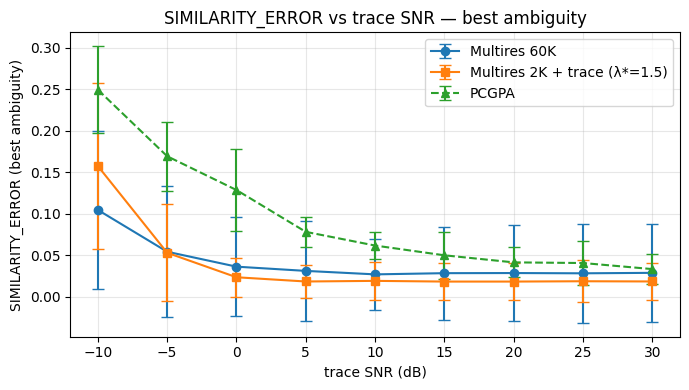

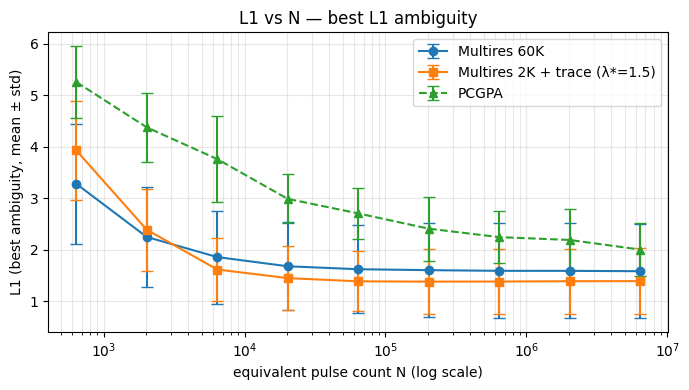

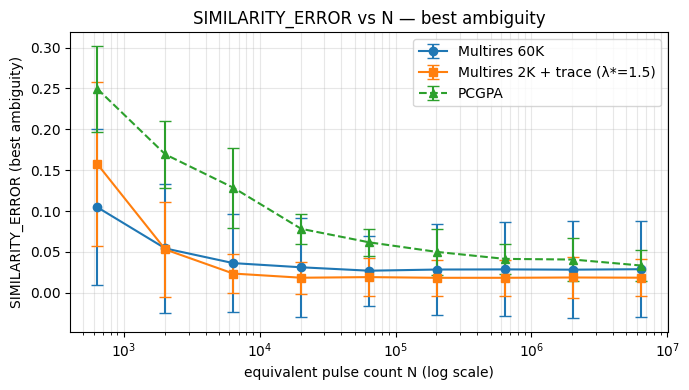

In [6]:
snr = sweep_60k.snr_sweep_db
pcgpa_snr = _pcgpa_z["snr_sweep_db"]
if not np.array_equal(snr, pcgpa_snr):
    raise ValueError("SNR grid mismatch between CNN and PCGPA sweeps")

curves_l1 = [
    (sweep_60k.cnn_l1_amb_m, sweep_60k.cnn_l1_amb_s, "-o", sweep_60k.experiment_name),
    (sweep_trace.cnn_l1_amb_m, sweep_trace.cnn_l1_amb_s, "-s", sweep_trace.experiment_name),
    (_pcgpa_z["pcgpa_l1_m"], _pcgpa_z["pcgpa_l1_s"], "--^", "PCGPA"),
]
curves_sim = [
    (sweep_60k.cnn_sim_amb_m, sweep_60k.cnn_sim_amb_s, "-o", sweep_60k.experiment_name),
    (sweep_trace.cnn_sim_amb_m, sweep_trace.cnn_sim_amb_s, "-s", sweep_trace.experiment_name),
    (_pcgpa_z["pcgpa_sim_m"], _pcgpa_z["pcgpa_sim_s"], "--^", "PCGPA"),
]

plot_metric_curves(
    snr,
    curves_l1,
    xlabel="trace SNR (dB)",
    ylabel="L1 (best ambiguity, mean ± std)",
    title="L1 vs trace SNR — best L1 ambiguity",
)
plot_metric_curves(
    snr,
    curves_sim,
    xlabel="trace SNR (dB)",
    ylabel="SIMILARITY_ERROR (best ambiguity)",
    title="SIMILARITY_ERROR vs trace SNR — best ambiguity",
)

n_equiv = np.array([snr_db_to_equivalent_n_pulses(float(s)) for s in snr])
plot_metric_curves(
    n_equiv,
    curves_l1,
    xlabel="equivalent pulse count N (log scale)",
    ylabel="L1 (best ambiguity, mean ± std)",
    title="L1 vs N — best L1 ambiguity",
    xscale="log",
)
plot_metric_curves(
    n_equiv,
    curves_sim,
    xlabel="equivalent pulse count N (log scale)",
    ylabel="SIMILARITY_ERROR (best ambiguity)",
    title="SIMILARITY_ERROR vs N — best ambiguity",
    xscale="log",
)


In [7]:
print(f"{'SNR (dB)':>10}  {'60K L1':>10}  {'2K+trace L1':>12}  {'PCGPA L1':>10}  "
      f"{'60K sim':>10}  {'2K+trace sim':>12}  {'PCGPA sim':>10}")
for i, s in enumerate(snr):
    print(
        f"{float(s):10.0f}  "
        f"{sweep_60k.cnn_l1_amb_m[i]:10.4f}  "
        f"{sweep_trace.cnn_l1_amb_m[i]:12.4f}  "
        f"{_pcgpa_z['pcgpa_l1_m'][i]:10.4f}  "
        f"{sweep_60k.cnn_sim_amb_m[i]:10.4f}  "
        f"{sweep_trace.cnn_sim_amb_m[i]:12.4f}  "
        f"{_pcgpa_z['pcgpa_sim_m'][i]:10.4f}"
    )


  SNR (dB)      60K L1   2K+trace L1    PCGPA L1     60K sim  2K+trace sim   PCGPA sim
       -10      3.2795        3.9291      5.2596      0.1047        0.1575      0.2495
        -5      2.2457        2.3869      4.3783      0.0544        0.0531      0.1694
         0      1.8554        1.6132      3.7607      0.0364        0.0236      0.1287
         5      1.6761        1.4461      2.9873      0.0313        0.0185      0.0783
        10      1.6190        1.3834      2.7048      0.0271        0.0193      0.0618
        15      1.6007        1.3776      2.4081      0.0285        0.0184      0.0501
        20      1.5876        1.3795      2.2433      0.0287        0.0184      0.0415
        25      1.5872        1.3853      2.1885      0.0284        0.0188      0.0408
        30      1.5804        1.3874      2.0017      0.0289        0.0186      0.0335


## 3b. Convergence rate (SIMILARITY_ERROR < 0.1 = 10%)

Fraction of test pulses with **best-ambiguity** SIMILARITY_ERROR below **0.1** (10%) vs. trace SNR and equivalent pulse count **N**.

**Test set:** 512 Gaussian synthetic pulses (`N_TEST`, `seed=0`). PCGPA uses the same 512 pulses (maxiter=200, 3 restarts). Cached in `CONVERGENCE_FRAC_NPZ`; set `RUN_CONVERGENCE_COMPUTE=True` to recompute.


In [8]:
RUN_CONVERGENCE_COMPUTE = False
SIM_CONVERGENCE_THRESHOLD = 0.1

if RUN_CONVERGENCE_COMPUTE:
    import subprocess
    cmd = [
        sys.executable,
        str(SRC / "scripts/compute_sim_convergence_fraction_sweep.py"),
        "--seed", str(SEED),
        "--n-test", str(N_TEST),
        "--threshold", str(SIM_CONVERGENCE_THRESHOLD),
        "--force",
    ]
    print("Running:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(SRC))
    if proc.returncode != 0:
        raise RuntimeError(f"convergence script failed (exit {proc.returncode})")

assert CONVERGENCE_FRAC_NPZ.exists(), f"Missing {CONVERGENCE_FRAC_NPZ} — run compute cell first."
conv = np.load(CONVERGENCE_FRAC_NPZ)
snr_conv = conv["snr_sweep_db"]
thr = float(conv["threshold"])
print(f"threshold={thr:.2f}  n_test={int(conv['n_test'])}")


threshold=0.10  n_test=512


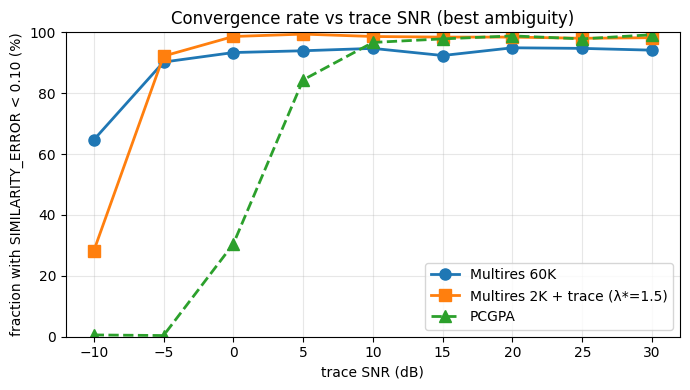

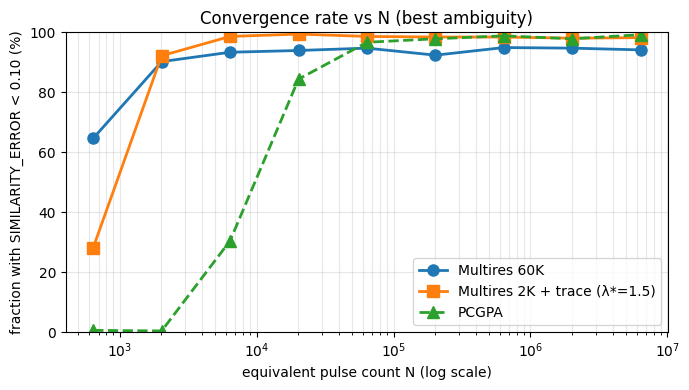

Multires 60K: [64.6 90.2 93.4 93.9 94.7 92.4 94.9 94.7 94.1] %
Multires 2K + trace (λ*=1.5): [28.1 92.2 98.6 99.4 98.6 98.4 98.4 98.  98.2] %
PCGPA: [ 0.6  0.4 30.5 84.4 96.7 97.9 98.8 97.9 99.2] %


In [9]:
with open(META_JSON, encoding="utf-8") as f:
    _rl = json.load(f)
_bv = np.array([e["best_val_l1"] for e in _rl], dtype=np.float64)
_lg = np.array([e["lam"] for e in _rl], dtype=np.float64)
lam_opt = float(_lg[int(np.argmin(_bv))])

series = [
    (conv["multires_60k"], "-o", "Multires 60K"),
    (conv["multires_2k_trace"], "-s", f"Multires 2K + trace (λ*={lam_opt:.2g})"),
    (conv["pcgpa"], "--^", "PCGPA"),
]

n_equiv_conv = np.array([snr_db_to_equivalent_n_pulses(float(s)) for s in snr_conv])

fig, ax = plt.subplots(figsize=(7, 4))
for y, fmt, lbl in series:
    ax.plot(snr_conv, y * 100.0, fmt, lw=2, ms=8, label=lbl)
ax.set_xlabel("trace SNR (dB)")
ax.set_ylabel(f"fraction with SIMILARITY_ERROR < {thr:.2f} (%)")
ax.set_title("Convergence rate vs trace SNR (best ambiguity)")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
for y, fmt, lbl in series:
    ax.plot(n_equiv_conv, y * 100.0, fmt, lw=2, ms=8, label=lbl)
ax.set_xscale("log")
ax.set_xlabel("equivalent pulse count N (log scale)")
ax.set_ylabel(f"fraction with SIMILARITY_ERROR < {thr:.2f} (%)")
ax.set_title("Convergence rate vs N (best ambiguity)")
ax.set_ylim(0, 100)
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

for y, _, lbl in series:
    print(lbl + ":", np.round(y * 100, 1), "%")


## 4. Example @ 5 dB — noisy trace + pulse reconstructions (3 models)

Separate **square** noisy trace (Energy [eV] vs τ [as]). Pulse panels: **Multires 60K**, **PCGPA**, **Multires 2K + trace loss** (λ*). Amplitude and phase on separate rows; L1 = best ambiguity.


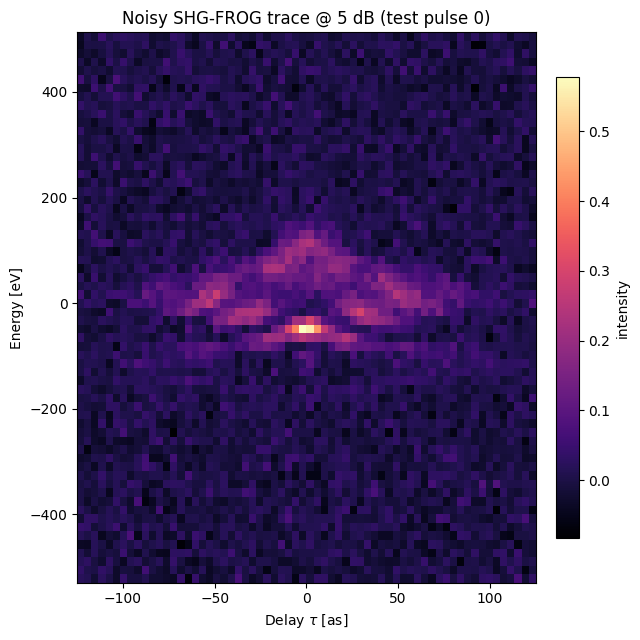

Multires 60K: L1 (best amb.) = 1.8415
Running PCGPA @ 5 dB (maxiter=200) …
PCGPA: L1 (best amb.) = 3.3347
Multires 2K + trace (lambda*=1.5): L1 (best amb.) = 1.1489


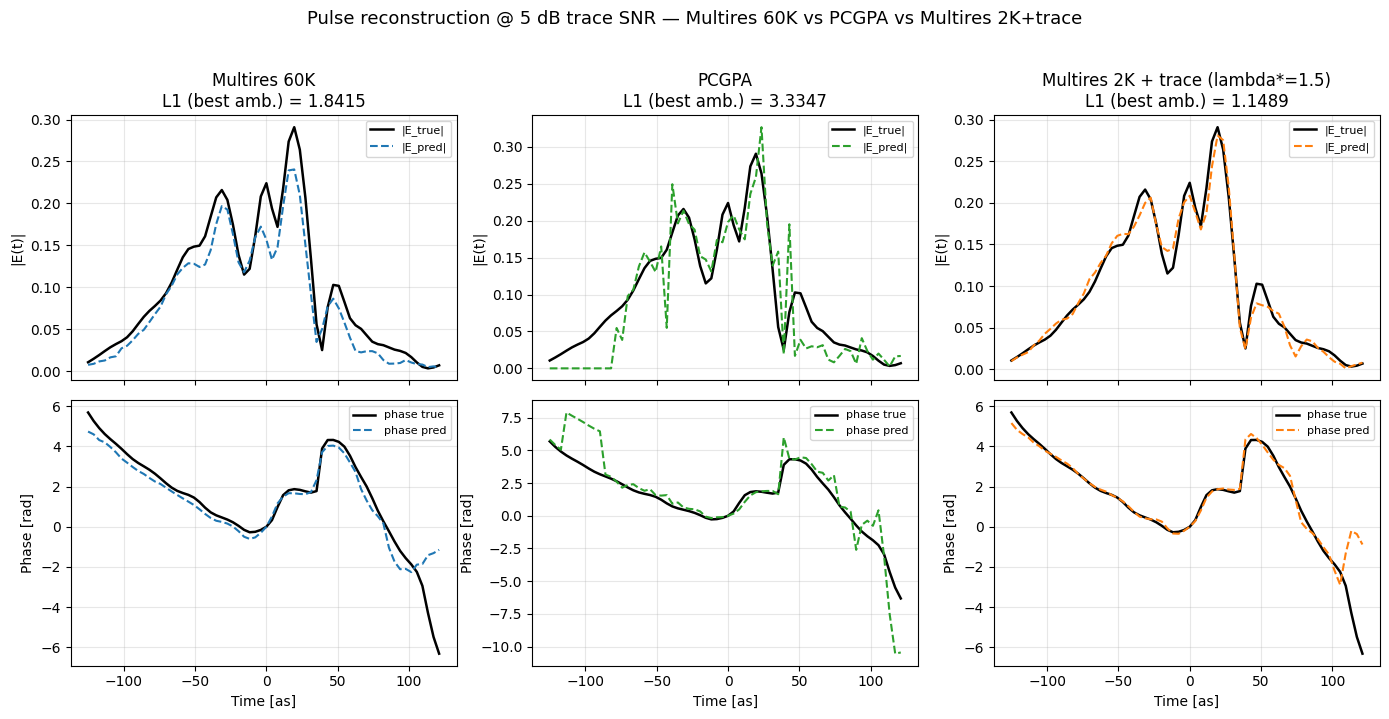

In [10]:
from pcgpa_reconstruct import reconstruct_pcgpa
from dataset_utils import PulseGridConfig, build_frog_dataloaders
from pulse_metrics import (
    best_l1_ambiguity,
    best_l1_ambiguity_field,
    packed_batch_to_complex,
    prepare_frog_trace_for_plot,
    unpack_packed_field,
    unwrap_phases_for_overlay,
)
from trace_noise import add_trace_noise_awgn
from train import build_model, load_checkpoint

ENERGY_SCALE_EV = 658.2  # omega [rad/as] -> Energy [eV], same as pulses_generator_NB.ipynb
PCGPA_MAXITER = 200
PCGPA_N_RESTARTS = 3

_PLOT_SNR_DB = 5.0
_plot_i = 0
_noise_seed = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n = 64
grid = PulseGridConfig(n=n)
DT = grid.dt
lam_opt = float(np.load(RESULTS_NPZ)["lambda_opt"])

bundle = build_frog_dataloaders(
    n_train=N_TRAIN,
    n_val=512,
    n_test=N_TEST,
    batch_size=64,
    seed=SEED,
    device=device,
    grid=grid,
)
I_test = bundle.test_loader.dataset.tensors[0]
E_test = bundle.test_loader.dataset.tensors[1]
t_vec = bundle.t_vec
w_vec = bundle.w_vec

I_clean_1 = I_test[_plot_i : _plot_i + 1].to(device)
torch.manual_seed(_noise_seed)
I_noisy = add_trace_noise_awgn(I_clean_1, _PLOT_SNR_DB)
i_noisy_np = I_noisy.squeeze(0).cpu().numpy()
e_true = unpack_packed_field(E_test[_plot_i].cpu().numpy())

_trace_plot, _tau_as, _ = prepare_frog_trace_for_plot(
    i_noisy_np, omega_axis=w_vec, dt=DT
)
# w_vec is already fftshift-centered (0 at middle); match trace_plot rows after fftshift(omega)
_omega_eV = np.asarray(w_vec, dtype=float) * ENERGY_SCALE_EV
_extent_ev = [_tau_as[0], _tau_as[-1], _omega_eV[0], _omega_eV[-1]]

# --- Figure 1: square noisy trace (64x64, separate plot) ---
fig_trace, ax_trace = plt.subplots(figsize=(6.5, 6.5))
im = ax_trace.imshow(
    _trace_plot, origin="lower", aspect="auto", extent=_extent_ev, cmap="magma",
)
ax_trace.set_title(f"Noisy SHG-FROG trace @ {_PLOT_SNR_DB:.0f} dB (test pulse {_plot_i})")
ax_trace.set_xlabel(r"Delay $\tau$ [as]")
ax_trace.set_ylabel("Energy [eV]")
fig_trace.colorbar(im, ax=ax_trace, fraction=0.046, pad=0.04, label="intensity")
fig_trace.tight_layout()
plt.show()

# --- Reconstructions: Multires 60K, PCGPA, Multires 2K + trace ---
_pred_colors = ["C0", "C2", "C1"]
_models = [
    ("Multires 60K", "cnn", SRC / "checkpoints/large_60k_multires_50ep.pt"),
    ("PCGPA", "pcgpa", None),
    (f"Multires 2K + trace (lambda*={lam_opt:.2g})", "cnn", OPT_CKPT),
]

_recs = []
for label, kind, ckpt_path in _models:
    if kind == "pcgpa":
        print(f"Running PCGPA @ {_PLOT_SNR_DB:.0f} dB (maxiter={PCGPA_MAXITER}) …")
        e_rec = reconstruct_pcgpa(
            i_noisy_np,
            dt=DT,
            maxiter=PCGPA_MAXITER,
            n_restarts=PCGPA_N_RESTARTS,
        )
    else:
        if ckpt_path == OPT_CKPT:
            ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
            model = build_model(n, device, model_name="multires")
            model.load_state_dict(ckpt["model_state_dict"])
        else:
            model, _ = load_checkpoint(ckpt_path, device=device)
        model.eval()
        with torch.no_grad():
            E_pred = model(I_noisy.unsqueeze(1))
        e_rec = packed_batch_to_complex(E_pred)[0]

    e_amb = best_l1_ambiguity_field(e_rec, e_true)
    l1 = best_l1_ambiguity(e_rec, e_true)
    ph_true, ph_rec = unwrap_phases_for_overlay(e_amb, e_true)
    _recs.append((label, e_amb, ph_true, ph_rec, l1))
    print(f"{label}: L1 (best amb.) = {l1:.4f}")

# --- Figure 2: amplitude (top) and phase (bottom), one column per model ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
ph_true_ref, _ = unwrap_phases_for_overlay(e_true, e_true)

for col, (color, (label, e_amb, ph_true, ph_rec, l1)) in enumerate(zip(_pred_colors, _recs)):
    ax_amp = axes[0, col]
    ax_amp.plot(t_vec, np.abs(e_true), "k-", lw=1.8, label="|E_true|")
    ax_amp.plot(t_vec, np.abs(e_amb), color=color, ls="--", lw=1.5, label="|E_pred|")
    ax_amp.set_ylabel("|E(t)|")
    ax_amp.set_title(f"{label}\nL1 (best amb.) = {l1:.4f}")
    ax_amp.legend(fontsize=8, loc="upper right")
    ax_amp.grid(True, alpha=0.3)

    ax_ph = axes[1, col]
    ax_ph.plot(t_vec, ph_true_ref, "k-", lw=1.8, label="phase true")
    ax_ph.plot(t_vec, ph_rec, color=color, ls="--", lw=1.5, label="phase pred")
    ax_ph.set_xlabel("Time [as]")
    ax_ph.set_ylabel("Phase [rad]")
    ax_ph.legend(fontsize=8, loc="upper right")
    ax_ph.grid(True, alpha=0.3)

fig.suptitle(
    f"Pulse reconstruction @ {_PLOT_SNR_DB:.0f} dB trace SNR — "
    "Multires 60K vs PCGPA vs Multires 2K+trace",
    y=1.02,
    fontsize=13,
)
fig.tight_layout()
plt.show()


## 5. Example @ 0 dB — noisy trace + pulse reconstructions (3 models)

Same code as section 4, with _PLOT_SNR_DB = 0.0. Section 4 (5 dB) stays above.

Separate **square** noisy trace (Energy [eV] vs tau [as]). Pulse panels: **Multires 60K**, **PCGPA**, **Multires 2K + trace loss** (lambda*).


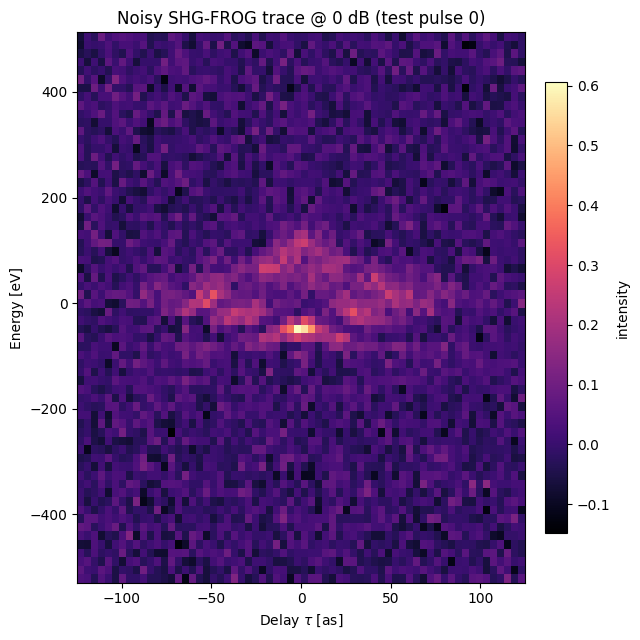

Multires 60K: L1 (best amb.) = 1.5994
Running PCGPA @ 0 dB (maxiter=200) …
PCGPA: L1 (best amb.) = 3.6763
Multires 2K + trace (lambda*=1.5): L1 (best amb.) = 1.2964


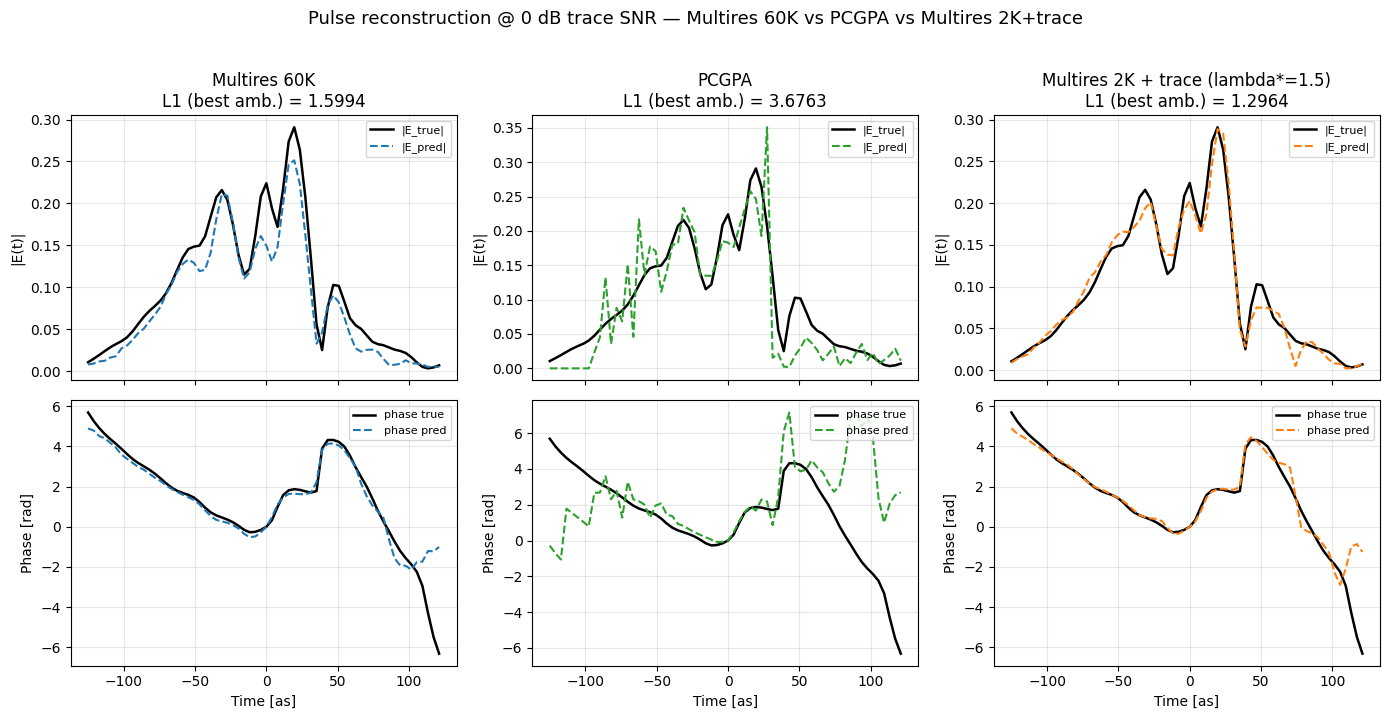

In [11]:
from pcgpa_reconstruct import reconstruct_pcgpa
from dataset_utils import PulseGridConfig, build_frog_dataloaders
from pulse_metrics import (
    best_l1_ambiguity,
    best_l1_ambiguity_field,
    packed_batch_to_complex,
    prepare_frog_trace_for_plot,
    unpack_packed_field,
    unwrap_phases_for_overlay,
)
from trace_noise import add_trace_noise_awgn
from train import build_model, load_checkpoint

ENERGY_SCALE_EV = 658.2  # omega [rad/as] -> Energy [eV], same as pulses_generator_NB.ipynb
PCGPA_MAXITER = 200
PCGPA_N_RESTARTS = 3

_PLOT_SNR_DB = 0.0
_plot_i = 0
_noise_seed = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n = 64
grid = PulseGridConfig(n=n)
DT = grid.dt
lam_opt = float(np.load(RESULTS_NPZ)["lambda_opt"])

bundle = build_frog_dataloaders(
    n_train=N_TRAIN,
    n_val=512,
    n_test=N_TEST,
    batch_size=64,
    seed=SEED,
    device=device,
    grid=grid,
)
I_test = bundle.test_loader.dataset.tensors[0]
E_test = bundle.test_loader.dataset.tensors[1]
t_vec = bundle.t_vec
w_vec = bundle.w_vec

I_clean_1 = I_test[_plot_i : _plot_i + 1].to(device)
torch.manual_seed(_noise_seed)
I_noisy = add_trace_noise_awgn(I_clean_1, _PLOT_SNR_DB)
i_noisy_np = I_noisy.squeeze(0).cpu().numpy()
e_true = unpack_packed_field(E_test[_plot_i].cpu().numpy())

_trace_plot, _tau_as, _ = prepare_frog_trace_for_plot(
    i_noisy_np, omega_axis=w_vec, dt=DT
)
# w_vec is already fftshift-centered (0 at middle); match trace_plot rows after fftshift(omega)
_omega_eV = np.asarray(w_vec, dtype=float) * ENERGY_SCALE_EV
_extent_ev = [_tau_as[0], _tau_as[-1], _omega_eV[0], _omega_eV[-1]]

# --- Figure 1: square noisy trace (64x64, separate plot) ---
fig_trace, ax_trace = plt.subplots(figsize=(6.5, 6.5))
im = ax_trace.imshow(
    _trace_plot, origin="lower", aspect="auto", extent=_extent_ev, cmap="magma",
)
ax_trace.set_title(f"Noisy SHG-FROG trace @ {_PLOT_SNR_DB:.0f} dB (test pulse {_plot_i})")
ax_trace.set_xlabel(r"Delay $\tau$ [as]")
ax_trace.set_ylabel("Energy [eV]")
fig_trace.colorbar(im, ax=ax_trace, fraction=0.046, pad=0.04, label="intensity")
fig_trace.tight_layout()
plt.show()

# --- Reconstructions: Multires 60K, PCGPA, Multires 2K + trace ---
_pred_colors = ["C0", "C2", "C1"]
_models = [
    ("Multires 60K", "cnn", SRC / "checkpoints/large_60k_multires_50ep.pt"),
    ("PCGPA", "pcgpa", None),
    (f"Multires 2K + trace (lambda*={lam_opt:.2g})", "cnn", OPT_CKPT),
]

_recs = []
for label, kind, ckpt_path in _models:
    if kind == "pcgpa":
        print(f"Running PCGPA @ {_PLOT_SNR_DB:.0f} dB (maxiter={PCGPA_MAXITER}) …")
        e_rec = reconstruct_pcgpa(
            i_noisy_np,
            dt=DT,
            maxiter=PCGPA_MAXITER,
            n_restarts=PCGPA_N_RESTARTS,
        )
    else:
        if ckpt_path == OPT_CKPT:
            ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
            model = build_model(n, device, model_name="multires")
            model.load_state_dict(ckpt["model_state_dict"])
        else:
            model, _ = load_checkpoint(ckpt_path, device=device)
        model.eval()
        with torch.no_grad():
            E_pred = model(I_noisy.unsqueeze(1))
        e_rec = packed_batch_to_complex(E_pred)[0]

    e_amb = best_l1_ambiguity_field(e_rec, e_true)
    l1 = best_l1_ambiguity(e_rec, e_true)
    ph_true, ph_rec = unwrap_phases_for_overlay(e_amb, e_true)
    _recs.append((label, e_amb, ph_true, ph_rec, l1))
    print(f"{label}: L1 (best amb.) = {l1:.4f}")

# --- Figure 2: amplitude (top) and phase (bottom), one column per model ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
ph_true_ref, _ = unwrap_phases_for_overlay(e_true, e_true)

for col, (color, (label, e_amb, ph_true, ph_rec, l1)) in enumerate(zip(_pred_colors, _recs)):
    ax_amp = axes[0, col]
    ax_amp.plot(t_vec, np.abs(e_true), "k-", lw=1.8, label="|E_true|")
    ax_amp.plot(t_vec, np.abs(e_amb), color=color, ls="--", lw=1.5, label="|E_pred|")
    ax_amp.set_ylabel("|E(t)|")
    ax_amp.set_title(f"{label}\nL1 (best amb.) = {l1:.4f}")
    ax_amp.legend(fontsize=8, loc="upper right")
    ax_amp.grid(True, alpha=0.3)

    ax_ph = axes[1, col]
    ax_ph.plot(t_vec, ph_true_ref, "k-", lw=1.8, label="phase true")
    ax_ph.plot(t_vec, ph_rec, color=color, ls="--", lw=1.5, label="phase pred")
    ax_ph.set_xlabel("Time [as]")
    ax_ph.set_ylabel("Phase [rad]")
    ax_ph.legend(fontsize=8, loc="upper right")
    ax_ph.grid(True, alpha=0.3)

fig.suptitle(
    f"Pulse reconstruction @ {_PLOT_SNR_DB:.0f} dB trace SNR — "
    "Multires 60K vs PCGPA vs Multires 2K+trace",
    y=1.02,
    fontsize=13,
)
fig.tight_layout()
plt.show()


## 6. Train @ SNR 0–30 dB (λ=1.5) + SNR sweep & convergence (<5%)

Fresh protocol (independent of sections 1–3b):
- Train **Multires 2K + trace** with **λ=1.5** fixed; training SNR uniform **0–30 dB** (previously 5–30 dB).
- Val: **200** pulses @ **15 dB**; early stopping on val pulse L1.
- **One combined compute** (`compute_sweep_and_convergence.py`) produces SNR sweeps **and** convergence fractions:
  - CNN (2K+trace, 60K): full **512**-pulse test set for sweep means; **60**-pulse subsample for convergence.
  - PCGPA: **60** pulses only (same subsample) — metrics reused for sweep **and** convergence.
- Convergence threshold: **SIMILARITY_ERROR < 0.05** (5%).


In [ ]:
# Section 6 paths & flags
TRAIN_SNR0_RANGE = (0.0, 30.0)
LAM_SNR0 = 1.5
SNR0_CKPT = SRC / "checkpoints/benchmark/multires_2k_noisy_trace_lam15_snr0.pt"
SNR0_META = SRC / "checkpoints/benchmark/multires_2k_noisy_trace_lam15_snr0_meta.json"
SNR0_SWEEP_CONV_NPZ = SRC / "checkpoints/benchmark/multires_2k_snr0_sweep_convergence.npz"
CONVERGENCE_N_SUB = 60
CONVERGENCE_THRESHOLD_S6 = 0.05
PCGPA_MAXITER_S6 = 200
PCGPA_N_RESTARTS_S6 = 3

RUN_SNR0_TRAINING = True  # set True to train λ=1.5 @ SNR 0–30 dB
RUN_SNR0_SWEEP_CONV = False   # set True to compute sweep + convergence


In [13]:
if RUN_SNR0_TRAINING:
    cmd = [
        sys.executable,
        str(SRC / "scripts/run_multires_2k_noisy_trace_lam15_snr0.py"),
        "--seed", str(SEED),
        "--n-train", str(N_TRAIN),
        "--n-val", str(N_VAL),
        "--train-snr-min", str(TRAIN_SNR0_RANGE[0]),
        "--train-snr-max", str(TRAIN_SNR0_RANGE[1]),
        "--val-snr-db", str(VAL_SNR_DB),
        "--lam", str(LAM_SNR0),
        "--max-epochs", str(MAX_EPOCHS),
        "--patience", str(PATIENCE),
        "--output", str(SNR0_CKPT),
        "--meta-json", str(SNR0_META),
    ]
    if FORCE_RETRAIN:
        cmd.append("--force")
    print("Running:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(SRC))
    if proc.returncode != 0:
        raise RuntimeError(f"training failed (exit {proc.returncode})")

assert SNR0_CKPT.exists(), f"Missing {SNR0_CKPT} — set RUN_SNR0_TRAINING=True"
with open(SNR0_META, encoding="utf-8") as f:
    _snr0_meta = json.load(f)
print(
    f"λ={LAM_SNR0:.2f}  train SNR [{TRAIN_SNR0_RANGE[0]:.0f}, {TRAIN_SNR0_RANGE[1]:.0f}] dB  "
    f"best_val_L1={_snr0_meta['best_val_l1']:.5f}  epoch={_snr0_meta['best_epoch']}"
)


Running: d:\Haim\Haim 3rd paper\Ultra-Fast project\.venv\Scripts\python.exe d:\Haim\Haim 3rd paper\Ultra-Fast project\src\scripts\run_multires_2k_noisy_trace_lam15_snr0.py --seed 0 --n-train 2048 --n-val 200 --train-snr-min 0.0 --train-snr-max 30.0 --val-snr-db 15.0 --lam 1.5 --max-epochs 200 --patience 25 --output d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\multires_2k_noisy_trace_lam15_snr0.pt --meta-json d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\multires_2k_noisy_trace_lam15_snr0_meta.json
λ=1.50  train SNR [0, 30] dB  best_val_L1=3.29230  epoch=173


In [15]:
if RUN_SNR0_SWEEP_CONV:
    cmd = [
        sys.executable,
        str(SRC / "scripts/compute_sweep_and_convergence.py"),
        "--seed", str(SEED),
        "--n-test", str(N_TEST),
        "--n-subsample", str(CONVERGENCE_N_SUB),
        "--threshold", str(CONVERGENCE_THRESHOLD_S6),
        "--ckpt-2k", str(SNR0_CKPT),
        "--pcgpa-maxiter", str(PCGPA_MAXITER_S6),
        "--pcgpa-n-restarts", str(PCGPA_N_RESTARTS_S6),
        "--output", str(SNR0_SWEEP_CONV_NPZ),
    ]
    print("Running:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(SRC))
    if proc.returncode != 0:
        raise RuntimeError(f"sweep/convergence failed (exit {proc.returncode})")

assert SNR0_SWEEP_CONV_NPZ.exists(), (
    f"Missing {SNR0_SWEEP_CONV_NPZ} — set RUN_SNR0_SWEEP_CONV=True"
)
sc = np.load(SNR0_SWEEP_CONV_NPZ)
snr_s6 = sc["snr_sweep_db"]
thr_s6 = float(sc["convergence_threshold"])
n_sub_s6 = int(sc["n_subsample"])
print(f"loaded sweep+conv  threshold={thr_s6:.2f}  n_sub={n_sub_s6}  n_test={int(sc['n_test'])}")


Running: d:\Haim\Haim 3rd paper\Ultra-Fast project\.venv\Scripts\python.exe d:\Haim\Haim 3rd paper\Ultra-Fast project\src\scripts\compute_sweep_and_convergence.py --seed 0 --n-test 512 --n-subsample 60 --threshold 0.05 --ckpt-2k d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\multires_2k_noisy_trace_lam15_snr0.pt --pcgpa-maxiter 200 --pcgpa-n-restarts 3 --output d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\multires_2k_snr0_sweep_convergence.npz
loaded sweep+conv  threshold=0.05  n_sub=60  n_test=512


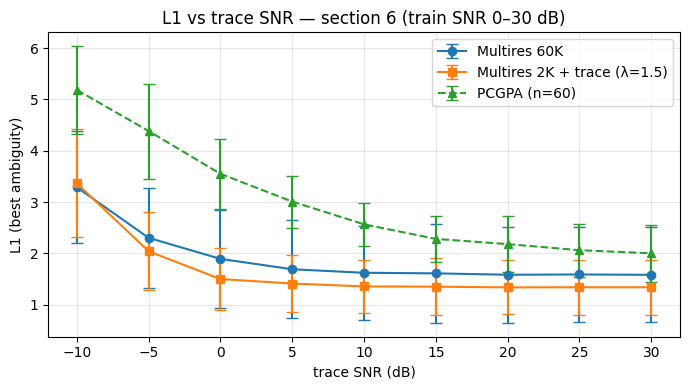

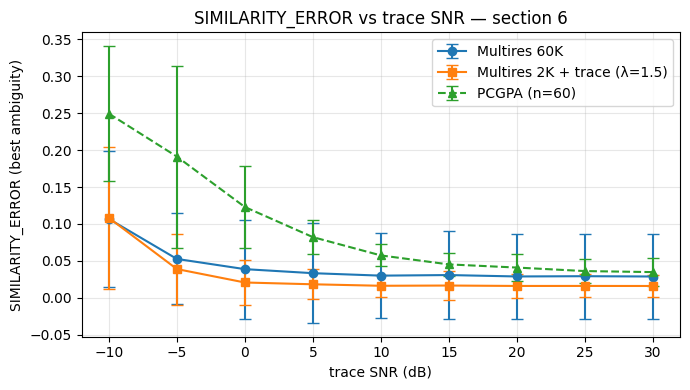

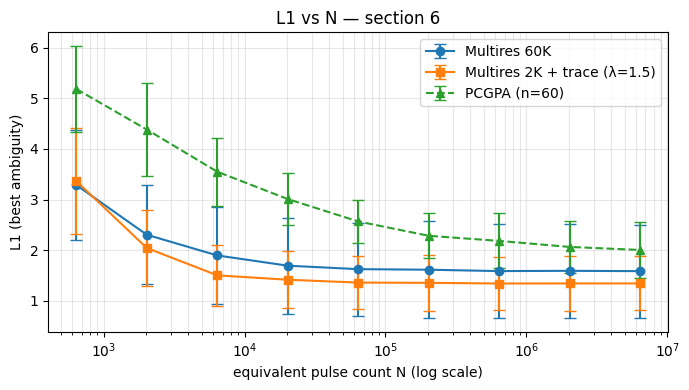

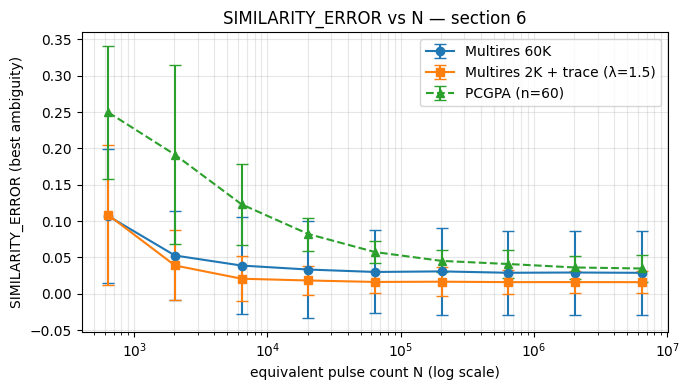

In [16]:
sweep_series_l1 = [
    (sc["m60k_l1_m"], sc["m60k_l1_s"], "-o", "Multires 60K"),
    (sc["trace_l1_m"], sc["trace_l1_s"], "-s", f"Multires 2K + trace (λ={LAM_SNR0:.2g})"),
    (sc["pcgpa_l1_m"], sc["pcgpa_l1_s"], "--^", f"PCGPA (n={n_sub_s6})"),
]
sweep_series_sim = [
    (sc["m60k_sim_m"], sc["m60k_sim_s"], "-o", "Multires 60K"),
    (sc["trace_sim_m"], sc["trace_sim_s"], "-s", f"Multires 2K + trace (λ={LAM_SNR0:.2g})"),
    (sc["pcgpa_sim_m"], sc["pcgpa_sim_s"], "--^", f"PCGPA (n={n_sub_s6})"),
]
n_equiv_s6 = np.array([snr_db_to_equivalent_n_pulses(float(s)) for s in snr_s6])

plot_metric_curves(
    snr_s6, sweep_series_l1,
    xlabel="trace SNR (dB)", ylabel="L1 (best ambiguity)",
    title="L1 vs trace SNR — section 6 (train SNR 0–30 dB)",
)
plot_metric_curves(
    snr_s6, sweep_series_sim,
    xlabel="trace SNR (dB)", ylabel="SIMILARITY_ERROR (best ambiguity)",
    title="SIMILARITY_ERROR vs trace SNR — section 6",
)
plot_metric_curves(
    n_equiv_s6, sweep_series_l1,
    xlabel="equivalent pulse count N (log scale)", ylabel="L1 (best ambiguity)",
    title="L1 vs N — section 6", xscale="log",
)
plot_metric_curves(
    n_equiv_s6, sweep_series_sim,
    xlabel="equivalent pulse count N (log scale)",
    ylabel="SIMILARITY_ERROR (best ambiguity)",
    title="SIMILARITY_ERROR vs N — section 6", xscale="log",
)


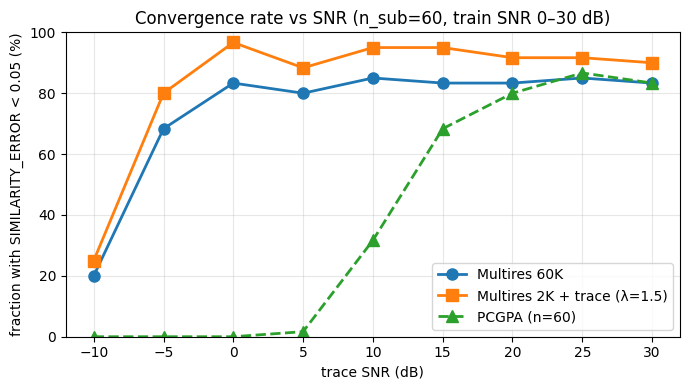

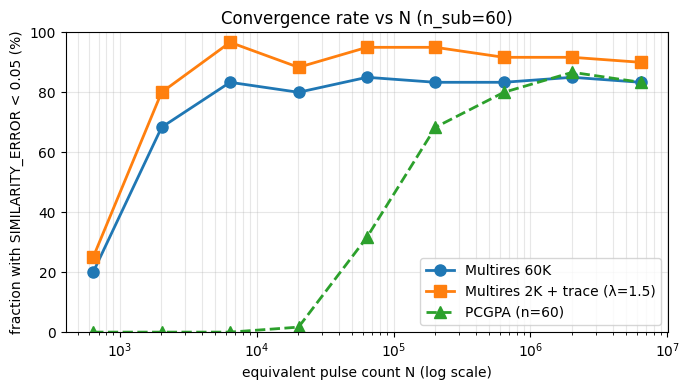

Multires 60K: [20.  68.3 83.3 80.  85.  83.3 83.3 85.  83.3] %
Multires 2K + trace (λ=1.5): [25.  80.  96.7 88.3 95.  95.  91.7 91.7 90. ] %
PCGPA (n=60): [ 0.   0.   0.   1.7 31.7 68.3 80.  86.7 83.3] %


In [17]:
conv_series = [
    (sc["m60k_conv_frac"], "-o", "Multires 60K"),
    (sc["trace_conv_frac"], "-s", f"Multires 2K + trace (λ={LAM_SNR0:.2g})"),
    (sc["pcgpa_conv_frac"], "--^", f"PCGPA (n={n_sub_s6})"),
]

fig, ax = plt.subplots(figsize=(7, 4))
for y, fmt, lbl in conv_series:
    ax.plot(snr_s6, y * 100.0, fmt, lw=2, ms=8, label=lbl)
ax.set_xlabel("trace SNR (dB)")
ax.set_ylabel(f"fraction with SIMILARITY_ERROR < {thr_s6:.2f} (%)")
ax.set_title(f"Convergence rate vs SNR (n_sub={n_sub_s6}, train SNR 0–30 dB)")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
for y, fmt, lbl in conv_series:
    ax.plot(n_equiv_s6, y * 100.0, fmt, lw=2, ms=8, label=lbl)
ax.set_xscale("log")
ax.set_xlabel("equivalent pulse count N (log scale)")
ax.set_ylabel(f"fraction with SIMILARITY_ERROR < {thr_s6:.2f} (%)")
ax.set_title(f"Convergence rate vs N (n_sub={n_sub_s6})")
ax.set_ylim(0, 100)
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

for y, _, lbl in conv_series:
    print(lbl + ":", np.round(y * 100, 1), "%")
